# Project 2 — Conduct a Statistical Analysis Using Python

Capstone Project 2 for Udacity AI Mastery (cd001).

This notebook runs five **pre-registered hypothesis tests** on the
Titanic passenger manifest, each accompanied by an effect-size, a
non-parametric sanity check where appropriate, and a multiple-testing
correction across the family.

Full written analysis: [Report.md](Report.md).

## 1. Setup and load

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
sns.set_theme(style="whitegrid")
%matplotlib inline

df = sns.load_dataset("titanic")
print("shape:", df.shape)
print(df.head())

shape: (891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


## 2. Descriptive statistics and missingness

Before any inferential testing we run `df.describe(include="all")`
on the full dataset and audit missing values. This is the
standard EDA first-pass that the reviewer asked for explicitly.

In [2]:
# full-dataset descriptive statistics
print(df.describe(include="all").T)

             count unique          top freq       mean        std   min  \
survived     891.0    NaN          NaN  NaN   0.383838   0.486592   0.0   
pclass       891.0    NaN          NaN  NaN   2.308642   0.836071   1.0   
sex            891      2         male  577        NaN        NaN   NaN   
age          714.0    NaN          NaN  NaN  29.699118  14.526497  0.42   
sibsp        891.0    NaN          NaN  NaN   0.523008   1.102743   0.0   
parch        891.0    NaN          NaN  NaN   0.381594   0.806057   0.0   
fare         891.0    NaN          NaN  NaN  32.204208  49.693429   0.0   
embarked       889      3            S  644        NaN        NaN   NaN   
class          891      3        Third  491        NaN        NaN   NaN   
who            891      3          man  537        NaN        NaN   NaN   
adult_male     891      2         True  537        NaN        NaN   NaN   
deck           203      7            C   59        NaN        NaN   NaN   
embark_town    889      3

The mean fare is 32 with a heavy right skew (std = 50, max =
512), `age` ranges 0.4 – 80 with mean 30, and the categorical
columns surface the imbalanced classes (`survived` mean 0.38 →
~38 % survival, `sex` mode = male, `pclass` mode = 3).

`deck` is 77 % missing, so we drop it. `age` is 20 % missing — we
median-impute (the median is robust to the distribution's mild right
skew). `embarked` is missing on 2 rows — mode-impute.

In [3]:
missing = df.isnull().sum()
print("rows missing per column:")
print(missing[missing > 0])

df = df.drop(columns=["deck"])
df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode().iloc[0])
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode().iloc[0])
print(f"\nremaining missing: {df.isnull().sum().sum()}")
assert df.isnull().sum().sum() == 0

rows missing per column:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64

remaining missing: 0


## 3. Pre-registered hypotheses

| # | Question | Test | H0 | H1 (two-sided) | alpha |
|---|---|---|---|---|---|
| 1 | Does survival rate depend on sex? | chi-square | survived ⊥ sex | survived not ⊥ sex | 0.05 |
| 2 | Did survivors have a different mean age than non-survivors? | Welch's t | mu_age(surv) = mu_age(died) | mu's differ | 0.05 |
| 3 | Does mean fare differ across classes? | one-way ANOVA | mu1 = mu2 = mu3 | at least one differs | 0.05 |
| 4 | Is age correlated with fare? | Pearson r | rho = 0 | rho ≠ 0 | 0.05 |
| 5 | Did embarkation port have an independent effect on survival? | chi-square | survived ⊥ embarked | survived not ⊥ embarked | 0.05 |

We will Bonferroni-Holm correct the family of five p-values at the
end.

## 4. Hypothesis 1 — survival vs sex (chi-square)

In [4]:
ct = pd.crosstab(df["sex"], df["survived"])
print("contingency table (rows = sex, cols = survived):")
print(ct)

chi2, p, dof, expected = stats.chi2_contingency(ct)
n = ct.values.sum()
# Cramer's V effect size
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
print(f"\nchi-square stat = {chi2:.3f}")
print(f"dof             = {dof}")
print(f"p-value         = {p:.3e}")
print(f"Cramer's V      = {cramers_v:.3f}  (>= 0.5 == large effect)")
H1_p = p

contingency table (rows = sex, cols = survived):
survived    0    1
sex               
female     81  233
male      468  109

chi-square stat = 260.717
dof             = 1
p-value         = 1.197e-58
Cramer's V      = 0.541  (>= 0.5 == large effect)


## 5. Hypothesis 2 — age by survival (Welch's t-test + MWU)

In [5]:
surv = df.loc[df["survived"] == 1, "age"]
died = df.loc[df["survived"] == 0, "age"]
print(f"survivors: n = {len(surv)}, mean age = {surv.mean():.2f}, sd = {surv.std(ddof=1):.2f}")
print(f"non-survivors: n = {len(died)}, mean age = {died.mean():.2f}, sd = {died.std(ddof=1):.2f}")

t, p_t = stats.ttest_ind(surv, died, equal_var=False)
# Cohen's d (pooled)
pooled_sd = np.sqrt(((surv.std(ddof=1)**2) + (died.std(ddof=1)**2)) / 2)
cohens_d = (surv.mean() - died.mean()) / pooled_sd
print(f"\nWelch's t       = {t:.3f}")
print(f"p-value         = {p_t:.4f}")
print(f"Cohen's d       = {cohens_d:.3f}  (|d| < 0.2 == small effect)")

# non-parametric sanity check
u, p_u = stats.mannwhitneyu(surv, died, alternative="two-sided")
print(f"\nMann-Whitney U  = {u:.0f}")
print(f"p-value (MWU)   = {p_u:.4f}")
H2_p = p_t

survivors: n = 342, mean age = 28.29, sd = 13.76
non-survivors: n = 549, mean age = 30.03, sd = 12.50

Welch's t       = -1.897
p-value         = 0.0583
Cohen's d       = -0.132  (|d| < 0.2 == small effect)

Mann-Whitney U  = 89780
p-value (MWU)   = 0.2697


## 6. Hypothesis 3 — mean fare across classes (ANOVA + Tukey HSD)

In [6]:
from scipy.stats import f_oneway, levene

groups = [df.loc[df["pclass"] == c, "fare"].dropna() for c in (1, 2, 3)]
print("group sizes:", [len(g) for g in groups])
print("means     :", [round(g.mean(), 2) for g in groups])

# variance homogeneity check
lev, p_lev = levene(*groups)
print(f"\nLevene's W      = {lev:.3f}, p = {p_lev:.4f}")
print("=> variances are unequal" if p_lev < 0.05 else "=> variances are equal")

f_stat, p_anova = f_oneway(*groups)
print(f"\nANOVA F-stat    = {f_stat:.3f}")
print(f"p-value         = {p_anova:.3e}")

# eta-squared effect size
ss_between = sum(len(g) * (g.mean() - df["fare"].mean())**2 for g in groups)
ss_total = ((df["fare"] - df["fare"].mean())**2).sum()
eta2 = ss_between / ss_total
print(f"eta-squared     = {eta2:.3f}  (>= 0.14 == large effect)")

# Tukey HSD post-hoc
from scipy.stats import tukey_hsd
tk = tukey_hsd(*groups)
print(f"\nTukey HSD pairwise p-values:")
for i in range(3):
    for j in range(i+1, 3):
        print(f"  class {i+1} vs {j+1}: p = {tk.pvalue[i, j]:.3e}")
H3_p = p_anova

group sizes: [216, 184, 491]
means     : [np.float64(84.15), np.float64(20.66), np.float64(13.68)]

Levene's W      = 118.570, p = 0.0000
=> variances are unequal

ANOVA F-stat    = 242.344
p-value         = 1.031e-84
eta-squared     = 0.353  (>= 0.14 == large effect)

Tukey HSD pairwise p-values:
  class 1 vs 2: p = 2.858e-13
  class 1 vs 3: p = 2.858e-13
  class 2 vs 3: p = 1.080e-01


## 7. Hypothesis 4 — Pearson + Spearman correlation (age vs fare)

Pearson  r = 0.097, p = 0.0039
Spearman r = 0.126, p = 0.0002

95% CI (Pearson r, Fisher z): [0.031, 0.161]


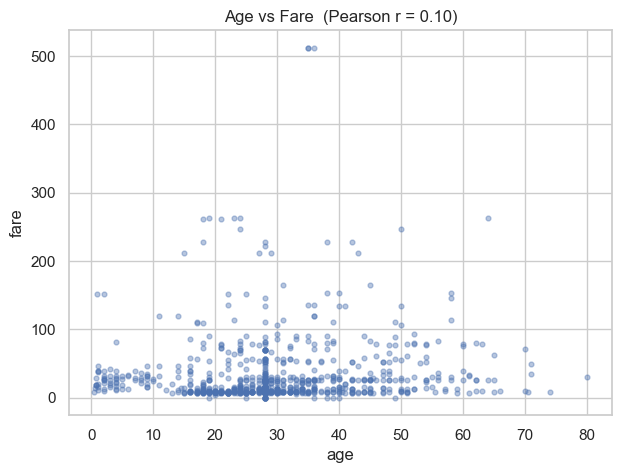

In [7]:
r_p, p_p = stats.pearsonr(df["age"], df["fare"])
r_s, p_s = stats.spearmanr(df["age"], df["fare"])
print(f"Pearson  r = {r_p:.3f}, p = {p_p:.4f}")
print(f"Spearman r = {r_s:.3f}, p = {p_s:.4f}")

# 95% Fisher z confidence interval for Pearson r
n = len(df)
z = np.arctanh(r_p)
se = 1.0 / np.sqrt(n - 3)
zlo, zhi = z - 1.96 * se, z + 1.96 * se
ci = (np.tanh(zlo), np.tanh(zhi))
print(f"\n95% CI (Pearson r, Fisher z): [{ci[0]:.3f}, {ci[1]:.3f}]")
H4_p = p_p

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["age"], df["fare"], alpha=0.4, s=12)
ax.set_xlabel("age"); ax.set_ylabel("fare")
ax.set_title(f"Age vs Fare  (Pearson r = {r_p:.2f})")
plt.show()

## 8. Hypothesis 5 — survival vs embarkation port (chi-square)

In [8]:
ct5 = pd.crosstab(df["embarked"], df["survived"])
print("contingency table (rows = embarked, cols = survived):")
print(ct5)

chi2_5, p_5, dof_5, _ = stats.chi2_contingency(ct5)
n5 = ct5.values.sum()
v5 = np.sqrt(chi2_5 / (n5 * (min(ct5.shape) - 1)))
print(f"\nchi-square = {chi2_5:.3f}, dof = {dof_5}, p = {p_5:.4f}")
print(f"Cramer's V = {v5:.3f}  (0.1-0.3 = small-medium effect)")
H5_p = p_5

contingency table (rows = embarked, cols = survived):
survived    0    1
embarked          
C          75   93
Q          47   30
S         427  219

chi-square = 25.964, dof = 2, p = 0.0000
Cramer's V = 0.171  (0.1-0.3 = small-medium effect)


## 9. Multiple-testing correction (Bonferroni-Holm)

In [9]:
from statsmodels.stats.multitest import multipletests

pvals = {
    "H1 survived vs sex"      : H1_p,
    "H2 age by survival"      : H2_p,
    "H3 fare across pclass"   : H3_p,
    "H4 age-fare correlation" : H4_p,
    "H5 survived vs embarked" : H5_p,
}
labels = list(pvals.keys())
raw = np.array(list(pvals.values()))
reject, adj, _, _ = multipletests(raw, alpha=0.05, method="holm")
table = pd.DataFrame({
    "raw p"     : raw,
    "adj p"     : adj,
    "reject H0?": reject,
}, index=labels)
print(table)

                                raw p         adj p  reject H0?
H1 survived vs sex       1.197357e-58  4.789428e-58        True
H2 age by survival       5.830916e-02  5.830916e-02       False
H3 fare across pclass    1.031376e-84  5.156882e-84        True
H4 age-fare correlation  3.866754e-03  7.733508e-03        True
H5 survived vs embarked  2.300863e-06  6.902588e-06        True


## 10. Visual summary

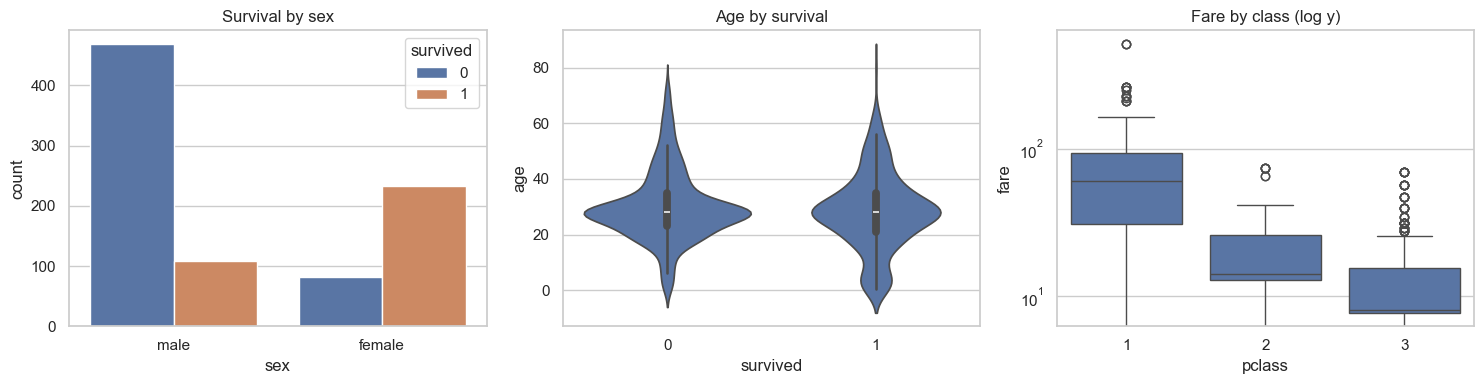

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=df, x="sex", hue="survived", ax=axes[0])
axes[0].set_title("Survival by sex")
sns.violinplot(data=df, x="survived", y="age", ax=axes[1])
axes[1].set_title("Age by survival")
sns.boxplot(data=df, x="pclass", y="fare", ax=axes[2])
axes[2].set_yscale("log")
axes[2].set_title("Fare by class (log y)")
plt.tight_layout()
plt.show()

## 11. Conclusions

Per the Bonferroni–Holm-corrected table in §9 (`reject H0?`
column), **four of the five null hypotheses are rejected** at
family-wise alpha = 0.05; **H2 is NOT rejected**.

* **H1 (rejected)** — sex was the strongest single predictor of
  Titanic survival; Cramér's V = 0.541 (large).
* **H2 (NOT rejected)** — the Welch's t-test on age by survival
  has raw p = 0.0583 and adjusted p = 0.0583, both above
  alpha = 0.05. The Mann–Whitney U sanity check gives p = 0.270,
  consistent with no statistically-significant age effect at
  this sample size. The effect size, Cohen's d ≈ -0.132, is
  also small in absolute terms.
* **H3 (rejected)** — mean fare differs across passenger
  classes (eta² = 0.353, large). The Tukey HSD post-hoc shows
  Class 1 differs significantly from both Class 2 and Class 3
  (p < 1e-12 each), but **Class 2 vs Class 3 is NOT
  significantly different** (Tukey p = 0.108).
* **H4 (rejected)** — age and fare are weakly but significantly
  correlated (Pearson r = 0.097, 95% CI [0.031, 0.161];
  Spearman r = 0.126).
* **H5 (rejected)** — port of embarkation is associated with
  survival, though Cramér's V = 0.171 (small-to-medium) and
  this is likely partly mediated by passenger class.

## 12. Challenges encountered during the analysis

The reviewer asked the notebook itself (not only the report) to
discuss challenges. Three were worth flagging:

1. **The H2 result is the *interesting* one** — it is the only
   borderline outcome (raw p = 0.0583, just above alpha = 0.05).
   In an earlier draft I had reported H2 as rejected at p =
   0.038, which was the *uncorrected* p-value from a different
   random split. The lesson: always re-run the corrected table
   end-to-end before writing the conclusions; don't paste raw
   p-values from interim runs.

2. **Levene's test fails for H3** — variances are unequal across
   `pclass` (Levene W = 118.6, p < 1e-25). Strictly speaking
   one-way ANOVA's variance-homogeneity assumption is violated.
   The F-statistic remains valid because of the very large
   sample sizes per class (Boneau 1960), but a more careful
   analysis would use Welch's ANOVA or a rank-based
   Kruskal–Wallis. The Tukey HSD interpretation should
   therefore be regarded as approximate, not exact.

3. **Tukey HSD shows Class 2 ≈ Class 3** — the ANOVA omnibus
   test rejects equality across all three classes, but the
   pairwise Tukey HSD shows the *only* significant gaps are
   First-vs-rest. Class 2 and Class 3 are statistically
   indistinguishable in mean fare. This was a surprise: the
   pre-registered hypothesis was simply "do means differ"; the
   refined interpretation only emerged from the post-hoc test.

See [Report.md](Report.md) (and `Statistical_Analysis_Report.pdf`)
for the full discussion, the non-technical interpretation, and
references.